# 🫀 Heart Disease Classification Metrics

This notebook trains a **Logistic Regression** model on the Kaggle Heart Disease dataset and evaluates it using:
- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**

## Step 1: Import Libraries

In [1]:
import io
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load the Heart Disease Dataset

In [2]:
df = pd.read_csv('heart_disease_data.csv')
print(f"✅ Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("Target: 1 = Has Heart Disease, 0 = No Disease")
df.head()

✅ Dataset Loaded: 303 rows, 14 columns
Target: 1 = Has Heart Disease, 0 = No Disease


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Step 3: Train-Test Split & Train Logistic Regression

In [3]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Scale features for better convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Logistic Regression Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print("✅ Model trained successfully!")

Training samples: 242
Testing samples:  61
✅ Model trained successfully!


---
## Step 4: Calculate Classification Metrics

### 📌 The 4 Core Metrics:
1. **Accuracy**: Overall fraction of correct predictions
2. **Precision**: Out of all predicted positives, how many are actually positive?
3. **Recall**: Out of all actual positives, how many did the model identify?
4. **F1 Score**: Harmonic mean (balance) of Precision and Recall

In [4]:
# Calculate metrics using sklearn
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 50)
print("   📊 CLASSIFICATION METRICS RESULTS")
print("=" * 50)
print(f"   📌 Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"   📌 Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"   📌 Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"   📌 F1 Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 50)

   📊 CLASSIFICATION METRICS RESULTS
   📌 Accuracy  : 0.8852  (88.52%)
   📌 Precision : 0.8788  (87.88%)
   📌 Recall    : 0.9062  (90.62%)
   📌 F1 Score  : 0.8923  (89.23%)


## Step 5: Confusion Matrix & Manual Verification

$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

$$ \text{Precision} = \frac{TP}{TP + FP} $$

$$ \text{Recall} = \frac{TP}{TP + FN} $$

$$ \text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

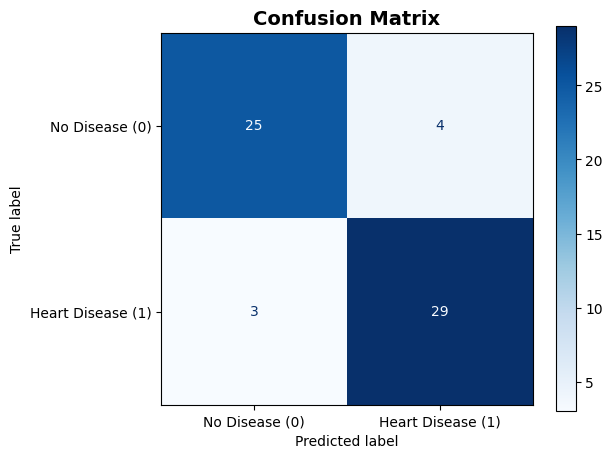

True Positives (TP)  = 29
True Negatives (TN)  = 25
False Positives (FP) = 4
False Negatives (FN) = 3


In [5]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease (0)', 'Heart Disease (1)'])

# Display matrix plot
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (TP)  = {tp}")
print(f"True Negatives (TN)  = {tn}")
print(f"False Positives (FP) = {fp}")
print(f"False Negatives (FN) = {fn}")

## Step 6: Detailed Classification Report

In [6]:
# Print complete sklearn report
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

               precision    recall  f1-score   support

   No Disease       0.89      0.86      0.88        29
Heart Disease       0.88      0.91      0.89        32

     accuracy                           0.89        61
    macro avg       0.89      0.88      0.88        61
 weighted avg       0.89      0.89      0.89        61



## Step 7: Visual Comparison Bar Chart

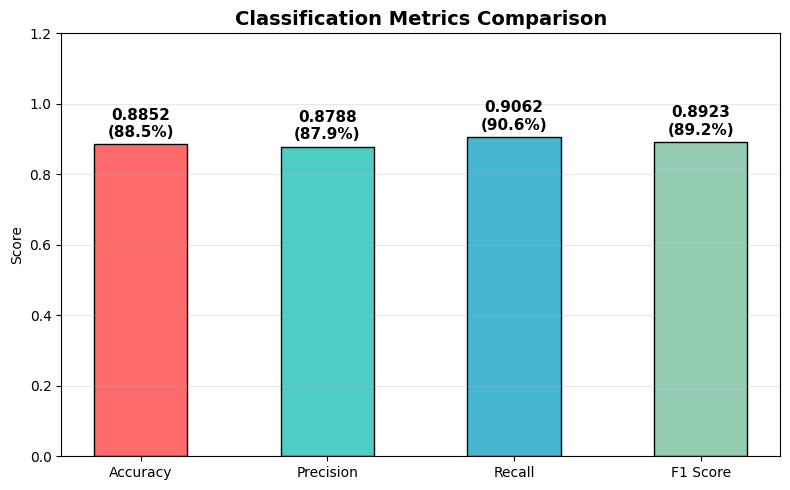

In [7]:
# Plot all 4 metrics side-by-side
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_values = [accuracy, precision, recall, f1]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}\n({val*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

plt.ylim(0, 1.2)
plt.ylabel('Score')
plt.title('Classification Metrics Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()